In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### Vector Quantizer (Codebook)

In [2]:
class VectorQuantizer(nn.Module):

    def __init__(self, num_embeddings, embedding_dim, commitment_cost=0.25):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_embeddings = num_embeddings
        self.commitment_cost = commitment_cost

        # Codebook
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.embedding.weight.data.uniform_(-1/num_embeddings, 1/num_embeddings)

    def forward(self, x):
        """
        x shape: [B, C, H, W]
        """
        # Reshape x to [B, H, W, C] and flatten it
        x = x.permute(0, 2, 3, 1).contiguous()
        x_flattened = x.view(-1, self.embedding_dim)

        # Calculate distances to cobebook efficiently; ||x − e||2 = ||x||2 + ||e||2 − 2x⋅e
        distances = torch.sum(x_flattened ** 2, dim=1, keepdim=True) + \
                    torch.sum(self.embedding.weight ** 2, dim=1) - \
                    2 * torch.matmul(x_flattened, self.embedding.weight.T)

        # Get the nearest indice to encode
        encoding_indices = torch.argmin(distances, dim=1).unsqueeze(1)
        quantized = self.embedding(encoding_indices).view(x.shape)

        # Compute loss: VQ loss + Commitment loss
        # z.detach() stops the gradient flow through tensor z (z treated as constant during backprop)
        # because quantization step is non-differentiable (i.e. argmin/argmax is non-differentiable)
        e_latent_loss = F.mse_loss(quantized.detach(), x) # Update encoder but not codebook
        q_latent_loss = F.mse_loss(quantized, x.detach()) # Update codebook but not encoder
        loss = q_latent_loss + self.commitment_cost * e_latent_loss # Encoder is reqularized

        # Straight-through estimator (STE) passes gradients through discrete/non-differentiable 
        # operations as identity to enable learning
        quantized = x + (quantized - x).detach() # Here x is trainable and (quantized - x) is frozen

        # Reshape quantized to [B, C, H, W]
        quantized = quantized.permute(0, 3, 1, 2).contiguous()

        return quantized, loss

### Tiny VQ-GAN

In [3]:
class TinyVQGAN(nn.Module):

    def __init__(self, num_embeddings=64, embedding_dim=16):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_embeddings = num_embeddings
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=embedding_dim, kernel_size=4, stride=2, padding=1)
        )
        self.quantizer = VectorQuantizer(num_embeddings, embedding_dim)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=embedding_dim, out_channels=32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=4, stride=2, padding=1),
            nn.Tanh() # Used to match the output range of the data [-1, 1]
        )

    def forward(self, x):
        z = self.encoder(x)
        quantized, vq_loss = self.quantizer(z)
        return self.decoder(quantized), vq_loss

### Discriminator (PatchGAN style)

In [4]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(in_channels=32, out_channels=1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

### Stage-I: Train w/ MNIST Data

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = TinyVQGAN().to(device)
discriminator = Discriminator().to(device)

optimizer_g = torch.optim.Adam(model.parameters(), lr=1e-3)
optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=1e-5)

train_loader = DataLoader(datasets.MNIST('./data', train=True, download=True, 
                          transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])), 
                          batch_size=64, shuffle=True)

for epoch in range(10):
    for i, (imgs, _) in enumerate(train_loader):
        imgs = imgs.to(device)

        # Train Generator and Vector Quantizer
        optimizer_g.zero_grad()
        reconstruction, vq_loss = model(imgs)

        # Generator loss: Reconstruction loss + VQ loss + Adversarial loss
        reconstruction_loss = F.mse_loss(reconstruction, imgs)
        g_pred = discriminator(reconstruction)
        g_adversarial_loss = F.binary_cross_entropy(g_pred, torch.ones_like(g_pred)) # Pretend every reconstructed image is REAL
        total_g_loss = reconstruction_loss + vq_loss + 0.1 * g_adversarial_loss

        total_g_loss.backward()
        optimizer_g.step()

        # Train Discriminator
        optimizer_d.zero_grad()
        dr_pred = discriminator(imgs)
        d_real_loss = F.binary_cross_entropy(dr_pred, torch.ones_like(dr_pred)) # Real classified as real
        df_pred = discriminator(reconstruction)
        # Do not send gradients to Generator
        d_fake_loss = F.binary_cross_entropy(df_pred.detach(), torch.zeros_like(df_pred)) # Fake classified as fake
        total_d_loss = (d_real_loss + d_fake_loss) / 2

        total_d_loss.backward()
        optimizer_d.step()

        if i % 500 == 0:
            print(f"Epoch {epoch} | G_Loss: {total_g_loss.item():.4f} | D_Loss: {total_d_loss.item():.4f}")

Epoch 0 | G_Loss: 0.8979 | D_Loss: 0.6160
Epoch 0 | G_Loss: 0.6060 | D_Loss: 0.8110
Epoch 1 | G_Loss: 0.2419 | D_Loss: 0.9810
Epoch 1 | G_Loss: 0.1618 | D_Loss: 1.2337
Epoch 2 | G_Loss: 0.1519 | D_Loss: 1.4556
Epoch 2 | G_Loss: 0.1376 | D_Loss: 1.7357
Epoch 3 | G_Loss: 0.1325 | D_Loss: 1.9487
Epoch 3 | G_Loss: 0.1286 | D_Loss: 2.2058
Epoch 4 | G_Loss: 0.1211 | D_Loss: 2.4308
Epoch 4 | G_Loss: 0.1185 | D_Loss: 2.6261
Epoch 5 | G_Loss: 0.1097 | D_Loss: 2.8280
Epoch 5 | G_Loss: 0.1042 | D_Loss: 3.0550
Epoch 6 | G_Loss: 0.1167 | D_Loss: 3.2085
Epoch 6 | G_Loss: 0.1168 | D_Loss: 3.3717
Epoch 7 | G_Loss: 0.1072 | D_Loss: 3.5849
Epoch 7 | G_Loss: 0.1023 | D_Loss: 3.7389
Epoch 8 | G_Loss: 0.0994 | D_Loss: 3.8708
Epoch 8 | G_Loss: 0.1003 | D_Loss: 4.0808
Epoch 9 | G_Loss: 0.0947 | D_Loss: 4.2992
Epoch 9 | G_Loss: 0.0919 | D_Loss: 4.4196


### MiniTransformer

In [6]:
class MiniTransformer(nn.Module):

    def __init__(self, num_embeddings=64, d_model=128, sequence_length=49): # 7 x 7 grid = 49
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings, d_model)
        self.pos_embedding = nn.Parameter(torch.zeros(1, sequence_length, d_model))

        # Attention is all you need based transformer
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=4, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer=encoder_layer, num_layers=3)
        self.proj = nn.Linear(d_model, num_embeddings)

    def forward(self, x):
        """
        x shape: [B, T] -> codebook indices
        """
        B, T = x.shape
        x = self.embedding(x) + self.pos_embedding[:, :T, :]

        # Causal mask (so that model can't see future)
        mask = torch.triu(torch.ones(T, T, device=x.device), 1).bool()
        x = self.transformer(x, mask=mask)
        
        return self.proj(x)


# Helpers
@torch.no_grad()
def get_codebook_indices(vq_gan, images):
    """
    Encodes images into discrete indices using Stage-I VQ-GAN
    """
    # Get image features
    z = vq_gan.encoder(images)

    # Reshape z to [B, H, W, C] and flatten it
    z_r = z.permute(0, 2, 3, 1).contiguous()
    z_flattened = z_r.view(-1, vq_gan.embedding_dim)

    # Calculate distances to cobebook efficiently; ||z − e||2 = ||z||2 + ||e||2 − 2z⋅e
    distances = torch.sum(z_flattened ** 2, dim=1, keepdim=True) + \
                torch.sum(vq_gan.quantizer.embedding.weight ** 2, dim=1) - \
                2 * torch.matmul(z_flattened, vq_gan.quantizer.embedding.weight.T)

    # Get codebook indices
    indices = torch.argmin(distances, dim=1)

    return indices.view(z.shape[0], -1) # [B, T], e.g. T = 7 x 7 = 49

### Stage-II: Train Transformer
- Freeze VQ-GAN
- Quantize images: Extract indices for each image
- Train Transformer

In [7]:
model.eval()
transformer = MiniTransformer().to(device)
optimizer = torch.optim.AdamW(transformer.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

for epoch in range(10):
    for i, (imgs, _) in enumerate(train_loader):
        imgs = imgs.to(device)

        # Quantize image (i.e. target indices)
        indices = get_codebook_indices(model, imgs) # [B, 49]

        # Setup input and target for autoregressive generation
        inputs = indices[:, :-1].to(device) # [0 to n-2]
        targets = indices[:, 1:].to(device) # [1 to n-1]

        logits = transformer(inputs)

        loss = criterion(logits.reshape(-1, logits.shape[-1]), targets.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if i % 500 == 0:
            print(f"Epoch {epoch} | Transformer_Loss: {loss.item():.4f}")

Epoch 0 | Transformer_Loss: 4.4101
Epoch 0 | Transformer_Loss: 1.5631
Epoch 1 | Transformer_Loss: 1.4549
Epoch 1 | Transformer_Loss: 1.5028
Epoch 2 | Transformer_Loss: 1.3202
Epoch 2 | Transformer_Loss: 1.3066
Epoch 3 | Transformer_Loss: 1.2493
Epoch 3 | Transformer_Loss: 1.2379
Epoch 4 | Transformer_Loss: 1.1618
Epoch 4 | Transformer_Loss: 1.1774
Epoch 5 | Transformer_Loss: 1.1701
Epoch 5 | Transformer_Loss: 1.1663
Epoch 6 | Transformer_Loss: 1.1476
Epoch 6 | Transformer_Loss: 1.1317
Epoch 7 | Transformer_Loss: 1.1162
Epoch 7 | Transformer_Loss: 1.0732
Epoch 8 | Transformer_Loss: 1.0205
Epoch 8 | Transformer_Loss: 1.0387
Epoch 9 | Transformer_Loss: 1.0687
Epoch 9 | Transformer_Loss: 1.1125


### Inference

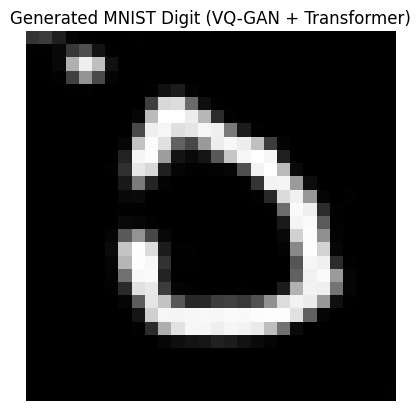

In [8]:
@torch.no_grad()
def generate_image(vq_gan, transformer, num_embeddings=64, sequence_length=49):
    vq_gan.eval()
    transformer.eval()

    # Start w/ a random seed token
    indices = torch.randint(0, num_embeddings, (1, 1)).to(device)

    # Generate next tokens autoregressively
    for _ in range(sequence_length - 1): # -1 because we have a random token index as start
        logits = transformer(indices)

        # Take the logits for the last token generated
        next_token_logits = logits[:, -1, :]

        # Sample from distributionn
        probs = F.softmax(next_token_logits, dim=-1)
        next_token_idx = torch.multinomial(probs, num_samples=1)

        # Append to the sequence
        indices = torch.cat([indices, next_token_idx], dim=1)

    # Reshape indices to grid
    grid_indices = indices.view(1, 7, 7)

    # Get vectors from the quantizer embeddings
    quantized = vq_gan.quantizer.embedding(grid_indices) # [1, 7, 7, E]

    # Reshape to [B, C, H, W] for decoder
    quantized = quantized.permute(0, 3, 1, 2).contiguous()
    
    # Decode using VQ-GAN decoder
    img = vq_gan.decoder(quantized)

    # De-normalize from [-1, 1] to [0, 1] for plotting
    img = (img + 1) / 2

    return img.cpu().squeeze()


# Generate image and plot
generated_image = generate_image(model, transformer)

plt.imshow(generated_image, cmap='gray')
plt.title("Generated MNIST Digit (VQ-GAN + Transformer)")
plt.axis('off')
plt.show()

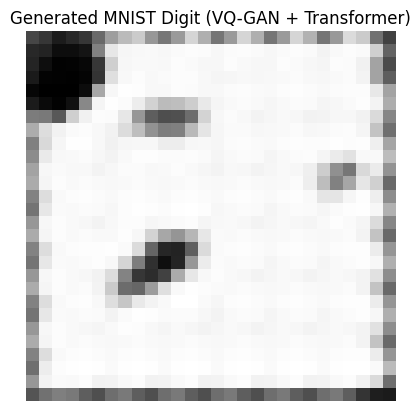

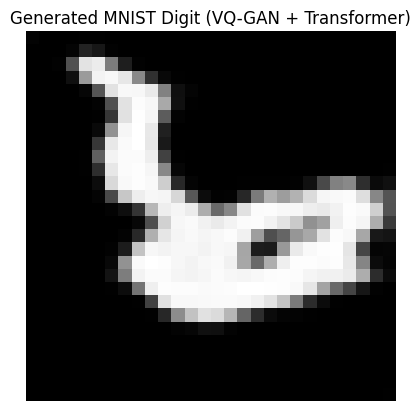

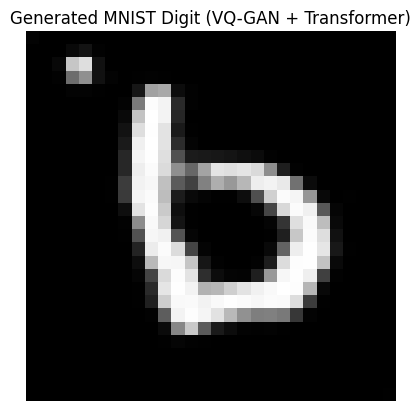

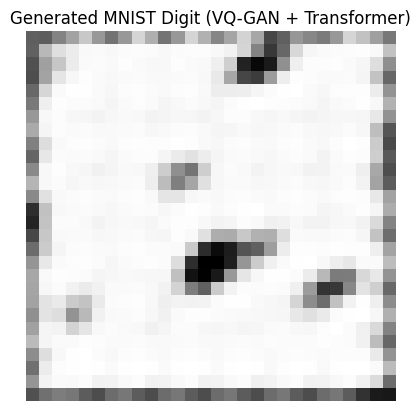

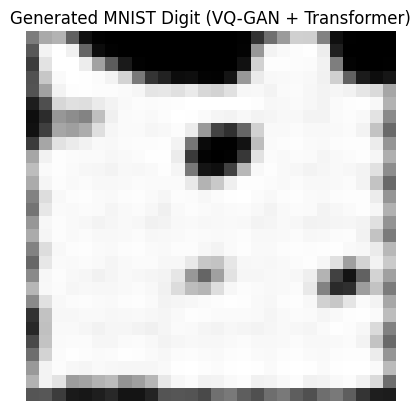

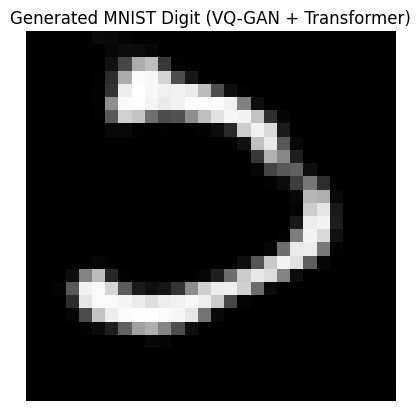

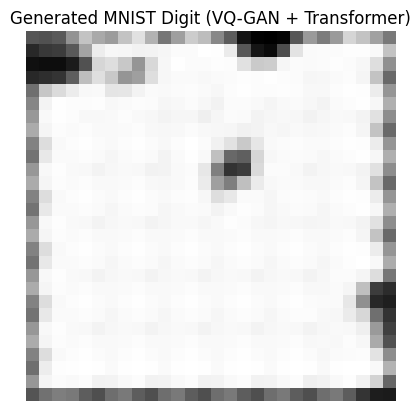

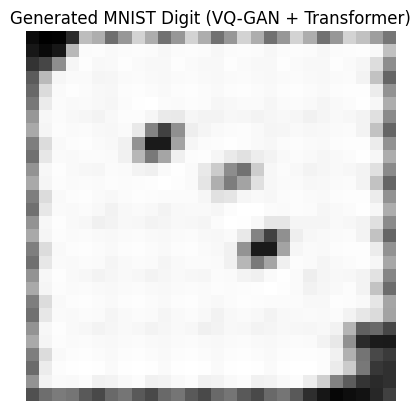

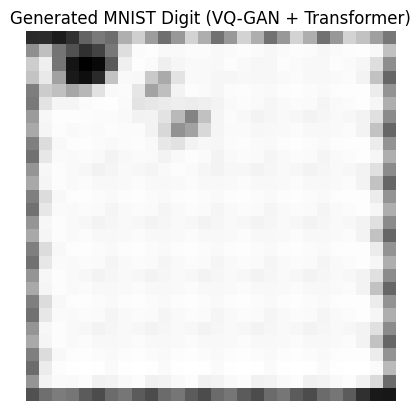

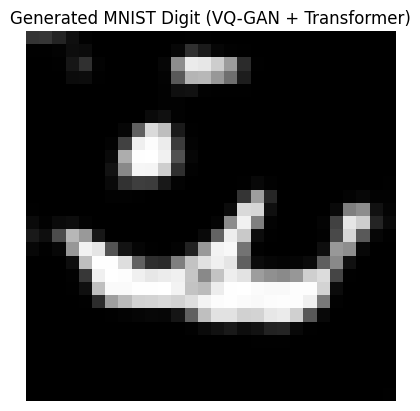

In [9]:
for _ in range(10):
    generated_image = generate_image(model, transformer)

    plt.imshow(generated_image, cmap='gray')
    plt.title("Generated MNIST Digit (VQ-GAN + Transformer)")
    plt.axis('off')
    plt.show()

# Scratch